In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO)

from pathlib import Path
import sys
import yaml

# Project root directory
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# Load project configuration
with open(PROJECT_ROOT / "config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# --- Data
from src.data.import_dataframe import import_dataframe
from src.data.merge_pathology_classes import merge_pathology_classes

# --- Features / Analysis
from src.analysis.compute_band_statistics import compute_band_statistics
from src.analysis.aggregate_band_statistics_per_class import aggregate_band_statistics_per_class
from src.analysis.experiment_types import ExperimentConfig, ExperimentResult
from src.analysis.build_X import build_X
from src.analysis.flatten_results import flatten_results
from src.analysis.run_cv_experiment import run_cv_experiment
from src.analysis.run_experiment_grid import run_experiment_grid

# --- Evaluation
from src.evaluation.build_accuracy_table import build_accuracy_table

# --- Visualization
from src.visualization.plot_mfbm_statistics_per_class import plot_mfbm_statistics_per_class
from src.visualization.plot_acoustic_features import plot_acoustic_features
from src.visualization.plot_3_confusion_matrices import plot_3_confusion_matrices
from src.visualization.plot_accuracy_bars import plot_accuracy_bars



In [2]:
# ---------------------------------------------------------
# Load precomputed MFBM features generated by Notebook 1
# ---------------------------------------------------------

dataset_name = config["data"]["corpus_name"]

df = import_dataframe(
    dataset_name,
    input_root=str(PROJECT_ROOT / "data" / "processed")
)


# Inspect dataframe structure
print(df.columns)

Index(['file', 'age', 'gender', 'group', 'class', 'meanF0', 'stddevF0',
       'localJitter', 'localShimmer', 'HNR', 'mfbm'],
      dtype='object')


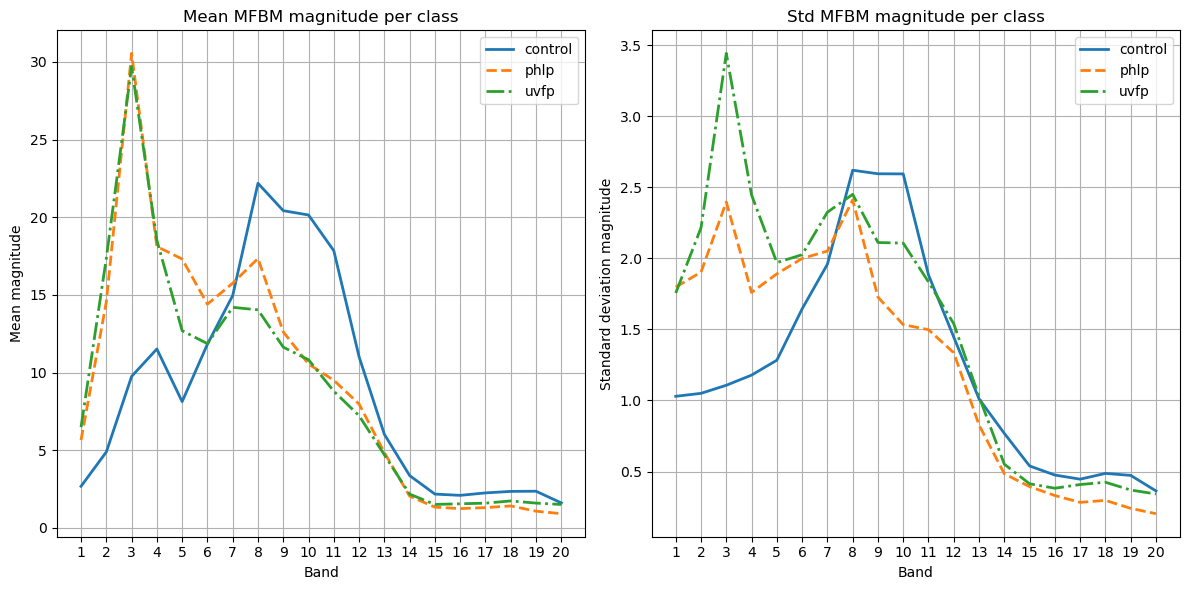

In [3]:
# Compute per-band mean and standard deviation statistics
df = compute_band_statistics(df)

# Merge Reinke's edema and vocal nodules into a single 'physio' class
merge_cfg = config['class_merging']

df = merge_pathology_classes(
    df,
    classes_to_merge=merge_cfg['groups_to_merge'],
    merged_label=merge_cfg['merged_label']
)

# Visualize mean and standard deviation profiles for each class
mean_dict, std_dict = aggregate_band_statistics_per_class(df)
plot_mfbm_statistics_per_class(
    mean_dict, 
    std_dict, 
    save_path=str(
        PROJECT_ROOT /
        config["results"]["figures_dir"] /
        "02_mean_std_per_class.png"
    )
)

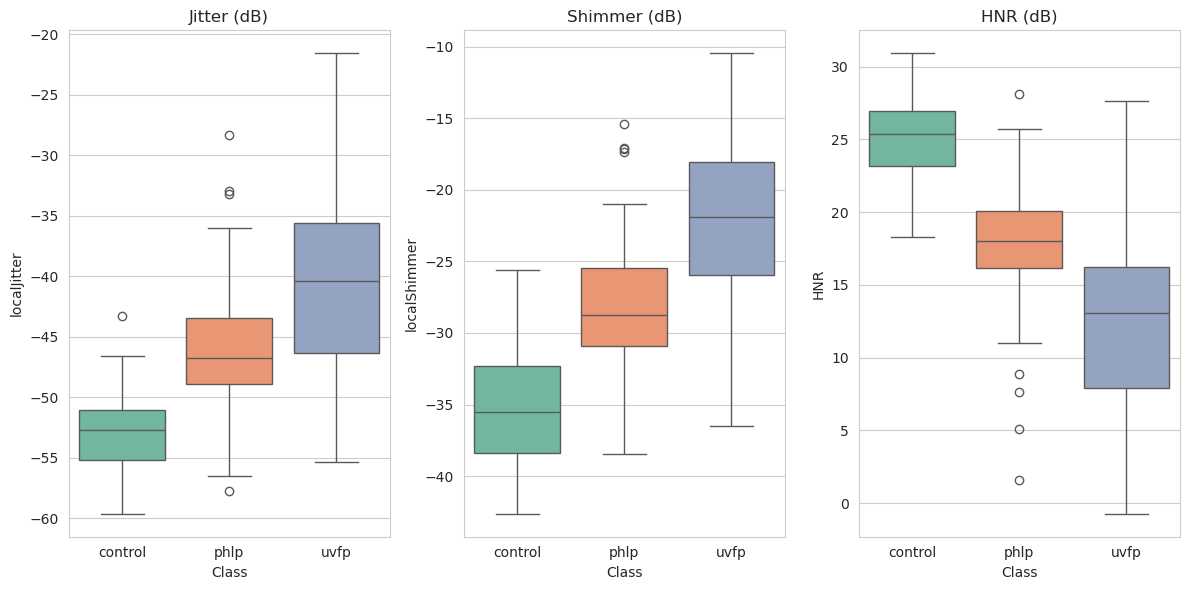

In [4]:
# Show acoustic features per class boxplots
# Jitter and shimmer were converted to dB for better visualization

acoustic_features = [
    ("localJitter", "Jitter (dB)"),
    ("localShimmer", "Shimmer (dB)"),
    ("HNR", "HNR (dB)")
]

plot_acoustic_features(
    df,
    acoustic_features,
    log_transform = ("localJitter", "localShimmer"),
    save_path=str(
        PROJECT_ROOT /
        config["results"]["figures_dir"] /
        "03_acoustic_features_per_class.png"
    )
)

In [5]:
# ------------------------------------------------------------------
# Experiment grid
# ------------------------------------------------------------------

# Feature sets to evaluate — each will be tested on every task
feature_sets = config["experiments"]["feature_sets"]

# Classification tasks — each entry maps a task name to the two groups
# involved. None means all classes are used (3-class classification).
tasks = config["experiments"]["tasks"]


# ------------------------------------------------------------------
# Run all experiments
# ------------------------------------------------------------------
all_results = run_experiment_grid(
    df,
    tasks=tasks,
    feature_sets=feature_sets,
    num_iters=config["experiments"]["num_iters"],
    print_report=False
)


In [6]:
# Convert results into tidy format
tidy_metrics_df, tidy_cm_df = flatten_results(all_results)

# Export results

tidy_metrics_df.to_csv(
    str(
        PROJECT_ROOT /
        config["results"]["metrics_dir"] /
        "tidy_metrics.csv"),
    index=False, 
    sep=";"
)

tidy_cm_df.to_csv(
    str(
        PROJECT_ROOT /
        config["results"]["metrics_dir"] /
        "tidy_cm.csv"),
    index=False, 
    sep=";"
)

In [7]:
# Make, show and save Accuracies Table

accuracy_table = build_accuracy_table(tidy_metrics_df)

accuracy_table.to_csv(
    str(
        PROJECT_ROOT /
        config["results"]["metrics_dir"] /
        "accuracy_table.csv"),
    index=False, 
    sep=";"
)

print(accuracy_table)

# Make, show and save AUC Table

from src.evaluation.build_auc_table import build_auc_table

auc_table = build_auc_table(tidy_metrics_df)

auc_table.to_csv(
    str(
        PROJECT_ROOT /
        config["results"]["metrics_dir"] /
        "auc_table.csv"),
    index=False, 
    sep=";"
)

print()
print(auc_table)

               3-Class   HE vs. PhLP   HE vs. UVFP PhLP vs. UVFP  \
features                                                           
Acoustic  67.67 ± 1.11   84.66 ± 1.0  90.24 ± 0.72  69.85 ± 1.29   
Spectral   66.7 ± 2.05  87.45 ± 1.89  85.03 ± 1.71   66.1 ± 2.77   
Combined  76.54 ± 1.67  94.84 ± 1.09  93.37 ± 0.77  73.55 ± 2.12   

         HE vs. All (*) PhLP vs. All (*) UVFP vs. All (*)  
features                                                   
Acoustic   88.08 ± 0.61     70.34 ± 1.12     76.93 ± 0.95  
Spectral   88.05 ± 1.24     73.36 ± 2.04     71.99 ± 2.14  
Combined   92.53 ± 0.72      80.1 ± 1.74     80.45 ± 1.59  

task     Control vs. PhLP Control vs. UVFP    PhLP vs. UVFP
features                                                   
Acoustic  0.9034 ± 0.0048  0.9599 ± 0.0032  0.7547 ± 0.0099
Spectral  0.9467 ± 0.0084  0.9380 ± 0.0102  0.7053 ± 0.0238
Combined  0.9678 ± 0.0044  0.9738 ± 0.0052  0.7674 ± 0.0136


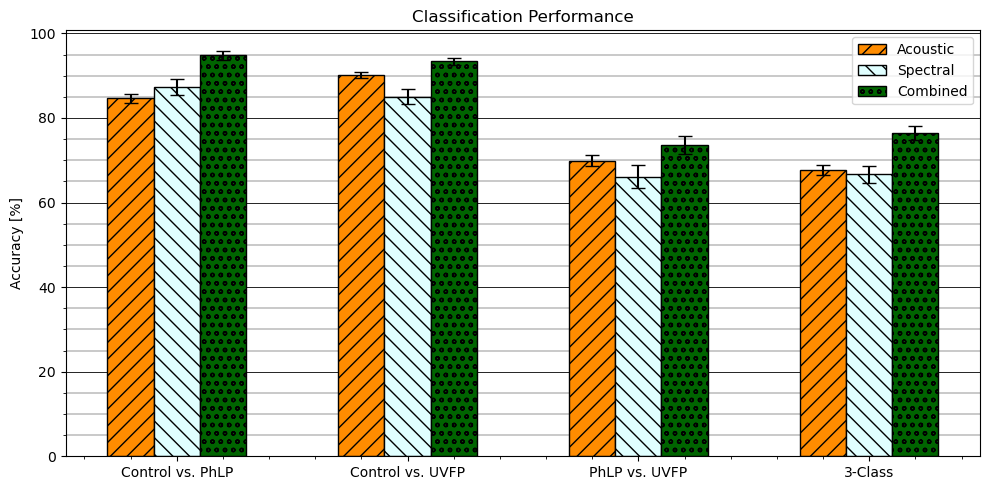

In [8]:
# Visualization

plot_accuracy_bars(
    tidy_metrics_df,
    save_path=str(
        PROJECT_ROOT /
        config["results"]["figures_dir"] /
        "04_accuracies_bar.png"
    )
)
    

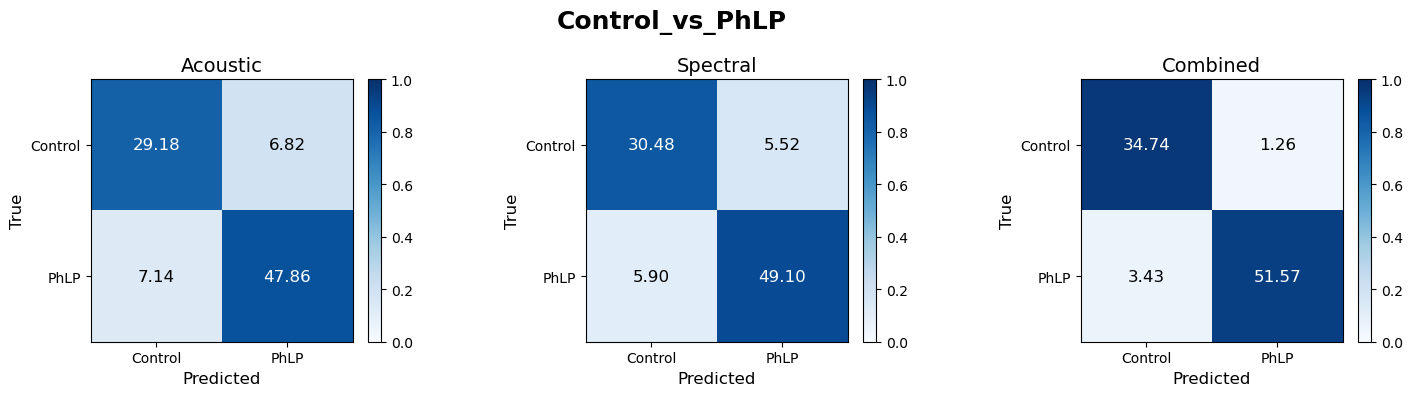

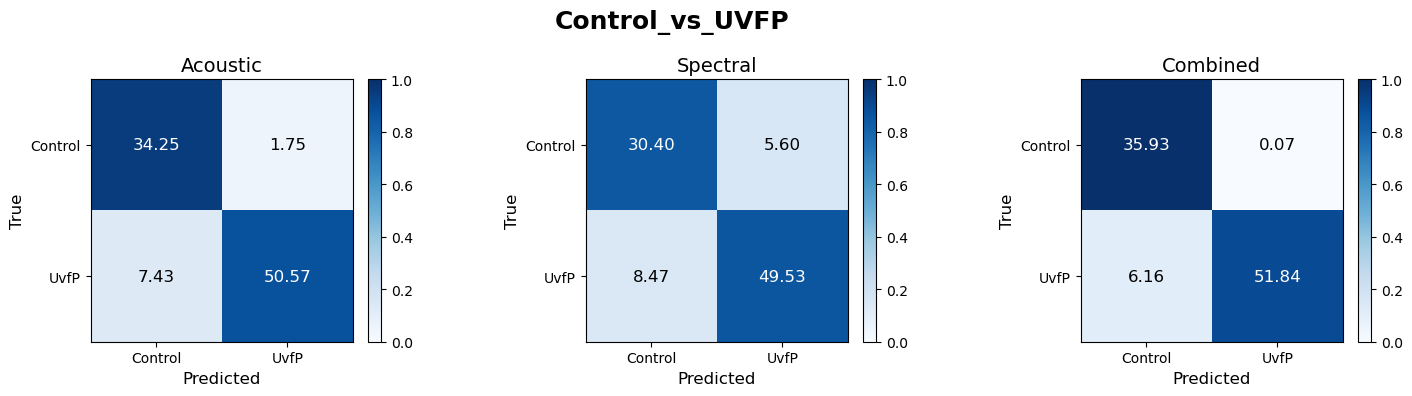

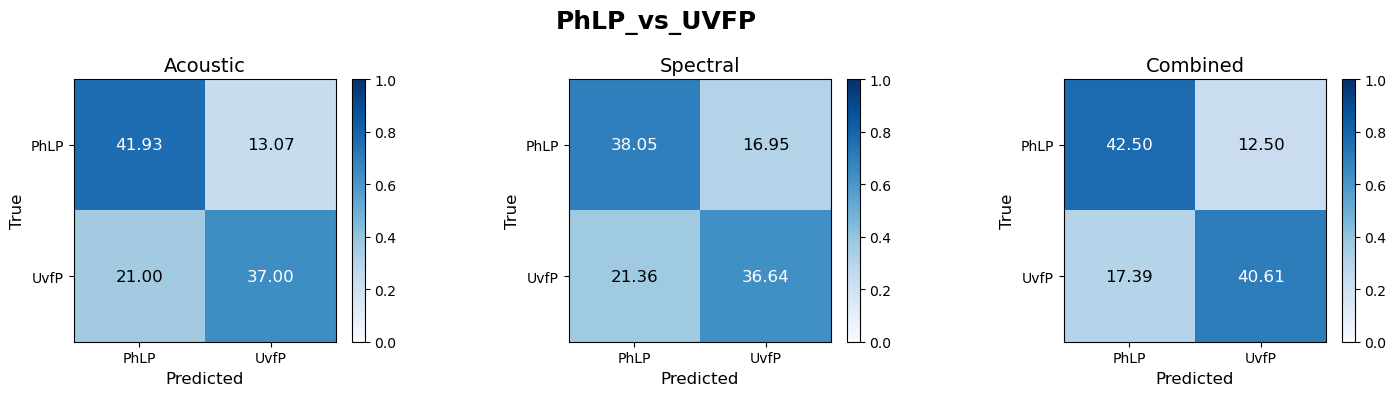

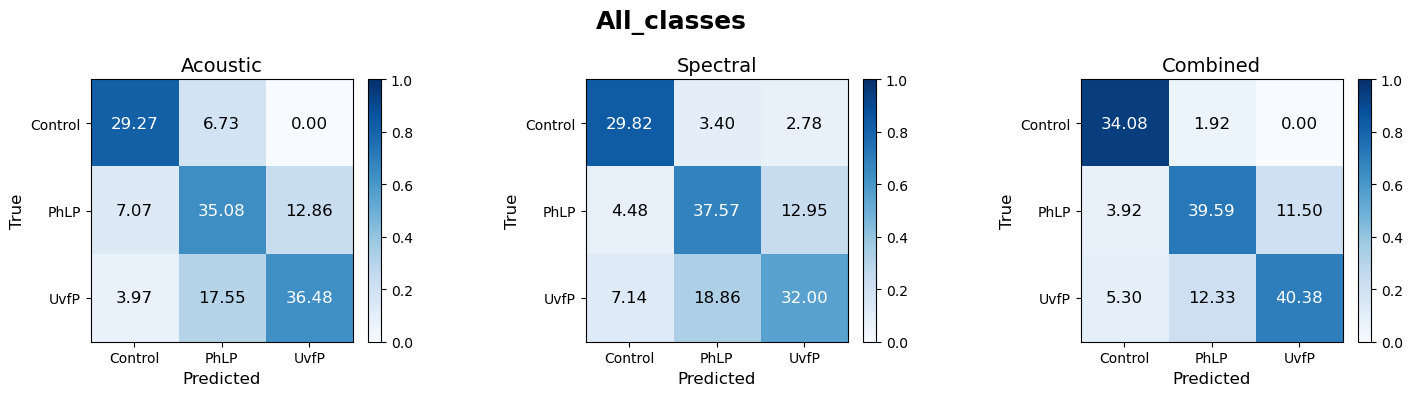

In [9]:
# Mapping to fix label capitalization, if needed
label_mapping = {"control": "Control", "phlp": "PhLP", "uvfp": "UvfP"}

tasks_to_plot = []
for task_name, classes in config["experiments"]["tasks"].items():
    # Se for "All_classes" (null no YAML), as labels são todas as conhecidas
    if classes is None:
        labels = list(label_mapping.values())
        filename = "05_ConfMatr_3_classes.png"
    else:
        labels = [label_mapping[c] for c in classes]
        filename = f"05_ConfMatr_{labels[0]}_vs_{labels[1]}.png"

    tasks_to_plot.append(
        {"task": task_name, "labels": labels, "filename": filename}
    )
    
# --- Generate and save all confusion matrices in a loop
figures_dir = PROJECT_ROOT / config["results"]["figures_dir"]

for item in tasks_to_plot:
    plot_3_confusion_matrices(
        tidy_cm_df,
        task_name=item["task"],
        class_names=item["labels"],
        save_path=str(figures_dir / item["filename"])
    )